# Online Retail — Seasonality Deep-Dive

**Context:** in [sales-forecaster](https://github.com/ctrl-kinge/sales-forecaster),
a 7-day seasonal-naive baseline (MAE 15,185) beat both a calendar-feature
regression (39,071) and a lag-28/35 regression (23,609). This notebook digs
into *why*: what seasonal structure does copying last week exploit, and what
does that imply for a fair evaluation setup?

**Questions:**
1. How strong is the day-of-week effect, and how stable is it over time?
2. What does the autocorrelation structure say about useful lags?
3. How much of the series is trend vs weekly cycle vs noise?

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append(str(Path.cwd().parent / "scripts"))
from download_data import download

df = pd.read_csv(download(), parse_dates=["InvoiceDate"])
sales = df[
    (~df["InvoiceNo"].astype(str).str.startswith("C")) & (df["Quantity"] > 0) & (df["UnitPrice"] > 0)
].copy()
sales["Revenue"] = sales["Quantity"] * sales["UnitPrice"]
daily = sales.set_index("InvoiceDate")["Revenue"].resample("D").sum()
print(f"{len(daily)} days, {daily.index[0].date()} .. {daily.index[-1].date()}")

Already cached: C:\Users\njung\source\repos\data-science-notebooks\data\online_retail.csv


374 days, 2010-12-01 .. 2011-12-09


## 1. Day-of-week profile

Mean revenue by weekday, with the spread shown as quartiles — the mean alone
can hide how *variable* each weekday is.

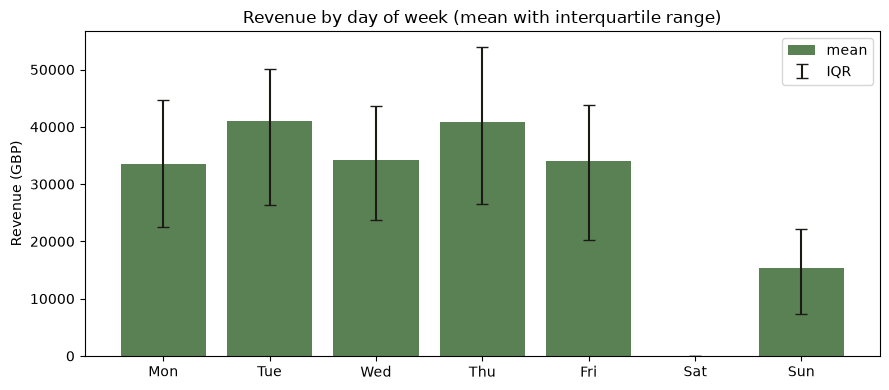

In [2]:
dow_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
by_dow = daily.groupby(daily.index.dayofweek)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(7), by_dow.mean(), color="#3d6b35", alpha=.85, label="mean")
q1, q3 = by_dow.quantile(.25), by_dow.quantile(.75)
ax.errorbar(range(7), by_dow.mean(), yerr=[by_dow.mean() - q1, q3 - by_dow.mean()],
            fmt="none", ecolor="#1c1a17", capsize=4, label="IQR")
ax.set_xticks(range(7), dow_names)
ax.set_title("Revenue by day of week (mean with interquartile range)")
ax.set_ylabel("Revenue (GBP)")
ax.legend()
plt.tight_layout()

In [3]:
profile = pd.DataFrame({"mean": by_dow.mean().round(0), "median": by_dow.median().round(0)})
profile.index = dow_names
print(profile)
print(f"\nSaturday share of days with zero revenue: "
      f"{(daily[daily.index.dayofweek == 5] == 0).mean():.0%}")

        mean   median
Mon  33577.0  29333.0
Tue  41106.0  35607.0
Wed  34281.0  28392.0
Thu  40799.0  36551.0
Fri  34080.0  28253.0
Sat      0.0      0.0
Sun  15355.0  12339.0

Saturday share of days with zero revenue: 100%


Saturdays are structurally closed (near-100% zero days) and Sunday runs well
below the weekday level — the weekly cycle is not subtle. Thursday is the
strongest day. Any model without day-of-week information is fighting blind.

## 2. Autocorrelation — which lags carry signal?

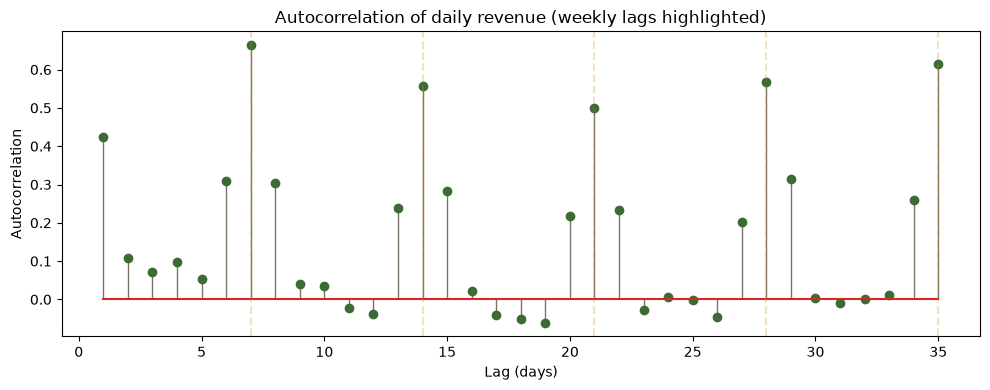

In [4]:
lags = range(1, 36)
acf = [daily.autocorr(lag=k) for k in lags]

fig, ax = plt.subplots(figsize=(10, 4))
markerline, stemlines, _ = ax.stem(list(lags), acf)
plt.setp(stemlines, color="#7d7466", linewidth=1)
plt.setp(markerline, color="#3d6b35")
for k in (7, 14, 21, 28, 35):
    ax.axvline(k, color="#c98a1b", alpha=.25, linestyle="--")
ax.set_title("Autocorrelation of daily revenue (weekly lags highlighted)")
ax.set_xlabel("Lag (days)")
ax.set_ylabel("Autocorrelation")
plt.tight_layout()

In [5]:
weekly_lags = {k: round(daily.autocorr(lag=k), 3) for k in (7, 14, 21, 28, 35)}
near_lags = {k: round(daily.autocorr(lag=k), 3) for k in (1, 2, 3)}
print("weekly-multiple lags:", weekly_lags)
print("short lags:          ", near_lags)

weekly-multiple lags: {7: np.float64(0.664), 14: np.float64(0.556), 21: np.float64(0.5), 28: np.float64(0.567), 35: np.float64(0.615)}
short lags:           {1: np.float64(0.425), 2: np.float64(0.107), 3: np.float64(0.073)}


The spikes at multiples of 7 dominate everything nearby: same-weekday
correlation stays high out to five weeks. This is exactly the structure
seasonal-naive uses — and why lag-7 features are the single most valuable
input a trained model can get. Lag-28/35 (what the horizon-safe regression
was allowed to use) are visibly weaker than lag-7: staleness costs signal.

## 3. Trend vs weekly cycle — a simple decomposition

Centered 7-day rolling mean as the trend; day-of-week means of the detrended
series as the seasonal component; what's left is noise.

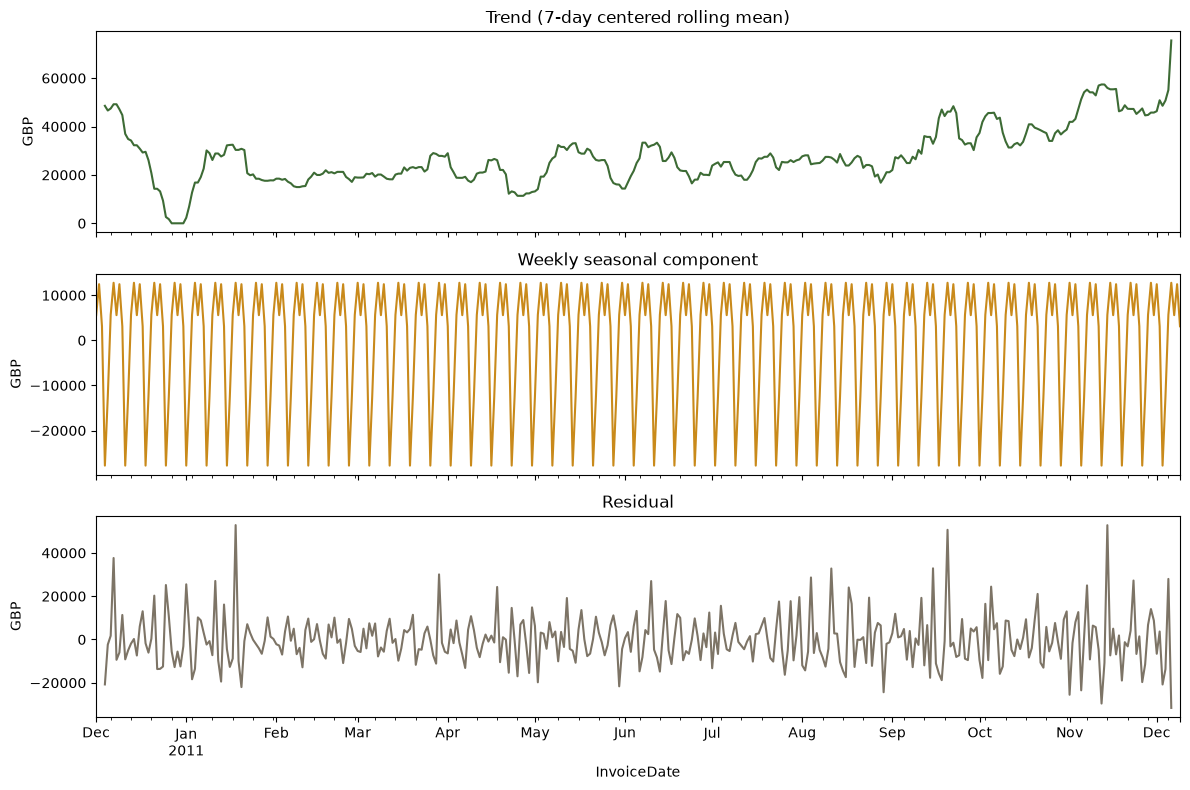

In [6]:
trend = daily.rolling(7, center=True).mean()
detrended = daily - trend
seasonal = detrended.groupby(detrended.index.dayofweek).transform("mean")
resid = detrended - seasonal

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
trend.plot(ax=axes[0], color="#3d6b35", title="Trend (7-day centered rolling mean)")
seasonal.plot(ax=axes[1], color="#c98a1b", title="Weekly seasonal component")
resid.plot(ax=axes[2], color="#7d7466", title="Residual")
for a in axes:
    a.set_ylabel("GBP")
plt.tight_layout()

In [7]:
var_parts = {
    "trend": float(trend.var()),
    "seasonal": float(seasonal.var()),
    "residual": float(resid.var()),
}
total = sum(var_parts.values())
for name, v in var_parts.items():
    print(f"{name:9s} {v / total:.0%} of decomposed variance")

trend     29% of decomposed variance
seasonal  41% of decomposed variance
residual  30% of decomposed variance


## Takeaways for sales-forecaster Phase 2d

1. **Evaluate at a 7-day horizon with a rolling origin.** The 28-day
   single-split evaluation forced models to use stale lags; weekly
   re-forecasting matches both the data's structure and how a supermarket
   would actually use forecasts.
2. **Lag-7 is the feature to beat.** Same-weekday correlation at lag 7 is
   the strongest signal in the series; at a 7-day horizon it becomes a legal
   feature, making the regression-vs-seasonal-naive fight fair.
3. **The residual is genuinely noisy.** A large share of day-to-day variance
   survives detrending and deseasonalizing — expectations for any model
   should be calibrated accordingly; near-zero error is not on the table.